# Load Data from Experimental Validation.

## Import Libraries.

In [41]:
import logging
import sys

import hydra
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from scipy import stats
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import torch


sys.path.insert(0, "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/shared_utils")
from experiment_utils import get_forward_model
from data_utils import transform_validation_data


### Define Settings Mapping.

In [2]:
settings_experiments_map = {
    216:"late_mgkPro_low_u",
    217:"late_mgkPro_high_u",
    218:"late_mgkPro_high_u",
    219: "EryPro_low_u",
    220: "EryPro_high_u",
    221: "EryPro_high_u",
    222: "HSC_low_u",
    223: "HSC_high_u",
    224: "HSC_high_u",
    225: "preProB_low_u",
    226: "preProB_high_u",
    225: "preProB_low_u",
    226: "preProB_high_u",
    227: "preProB_high_u",
}

### Read Configurations.

In [3]:
with hydra.initialize(
    config_path="../../inverse/loss_guidance/config"
):
    config = hydra.compose(
        config_name="run_inverse_constrained",
        overrides=[
            "paths=bloodplus_fm",
            "annotation=bloodplus",
            "sampling.N=10",
            "sampling.num_time_steps=20",
            "forward_model.num_time_steps=20",
            "constraints=default_all_cols"
        ]
    )
scatter_columns = config.annotation.scatter_columns
protocol_columns = config.annotation.protocol_columns

/tmp/ipykernel_892761/1785177493.py:1: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with hydra.initialize(


### Load Forward Model.

In [4]:
logger = logging.getLogger(__name__)

forward_model, (
    flow_matching,
    target_prediction_model
) = get_forward_model(config, logger=logger)

### Fit Label Encoder.

In [5]:
# Prepare label encoder
ct_le = LabelEncoder()
ct_values = target_prediction_model.train_data.adata.obs["cell_type"].values
ct_le.fit(ct_values)
classes = np.array(ct_le.classes_.tolist())


## Read Data.

### Read Original Annotated Data.

In [12]:
adata_path_500k_orig = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/data/gdrive/new_dataset/BloodPlus_celltype_pm_500k_filtered_.h5ad"
adata_500k_orig = sc.read_h5ad(adata_path_500k_orig)
adata_500k_orig

AnnData object with n_obs × n_vars = 471836 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'leiden', 'leiden_sub', 'leiden_old', 'cell_type'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'leiden_colors_old',

### Read Subset of Data.

In [6]:
adata_path_500k = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/data/gdrive/loop2/BloodPlus_Loop2_logicle_500k.h5ad"
adata_500k = sc.read_h5ad(adata_path_500k)
adata_500k

AnnData object with n_obs × n_vars = 499992 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'meta', 'processing_steps'
    layers: 'positives', 'raw'

### Read Full Data.

In [7]:
adata_path_full = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/data/gdrive/loop2/BloodPlus_Loop2_logicle.h5ad"
adata_full = sc.read_h5ad(adata_path_full)
adata_full

AnnData object with n_obs × n_vars = 4070966 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'meta', 'processing_steps'
    layers: 'positives', 'raw'

## Classify Data.

### Transform Data.

In [17]:
cell_repr = "X_channel_standardized+X_scatter_standardized"
train_adata_g = target_prediction_model.train_data.adata
adata_500k = transform_validation_data(
    scatter_columns,
    train_adata_g,
    adata_500k,
    logger=None,
)
X_500k = adata_500k.obsm[cell_repr]


### Classify.

In [ ]:
ct_labels_list = []
chunck_size = 50_000
for chunck_idx in range(0, X_500k.shape[0], chunck_size):
    x_batch = X_500k[chunck_idx:chunck_idx+chunck_size]
    x_batch = torch.from_numpy(
        x_batch
    ).to(torch.float).to(target_prediction_model.device)

    with torch.no_grad():
        ct_logits = target_prediction_model.predict(x_batch)["cell_type"]
    ct_probs = torch.nn.functional.softmax(ct_logits, dim=1)
    ct_label = ct_probs.argmax(1).detach().cpu().numpy()
    ct_pred = ct_le.inverse_transform(ct_label)

    ct_labels_list.append(ct_pred)

ct_pred_500k = np.concatenate(ct_labels_list, axis=0)
adata_500k.obs["pred_cell_type"] = ct_pred_500k


## Plot UMAP with scatter features.

### Plot UMAP with Scatter Features.

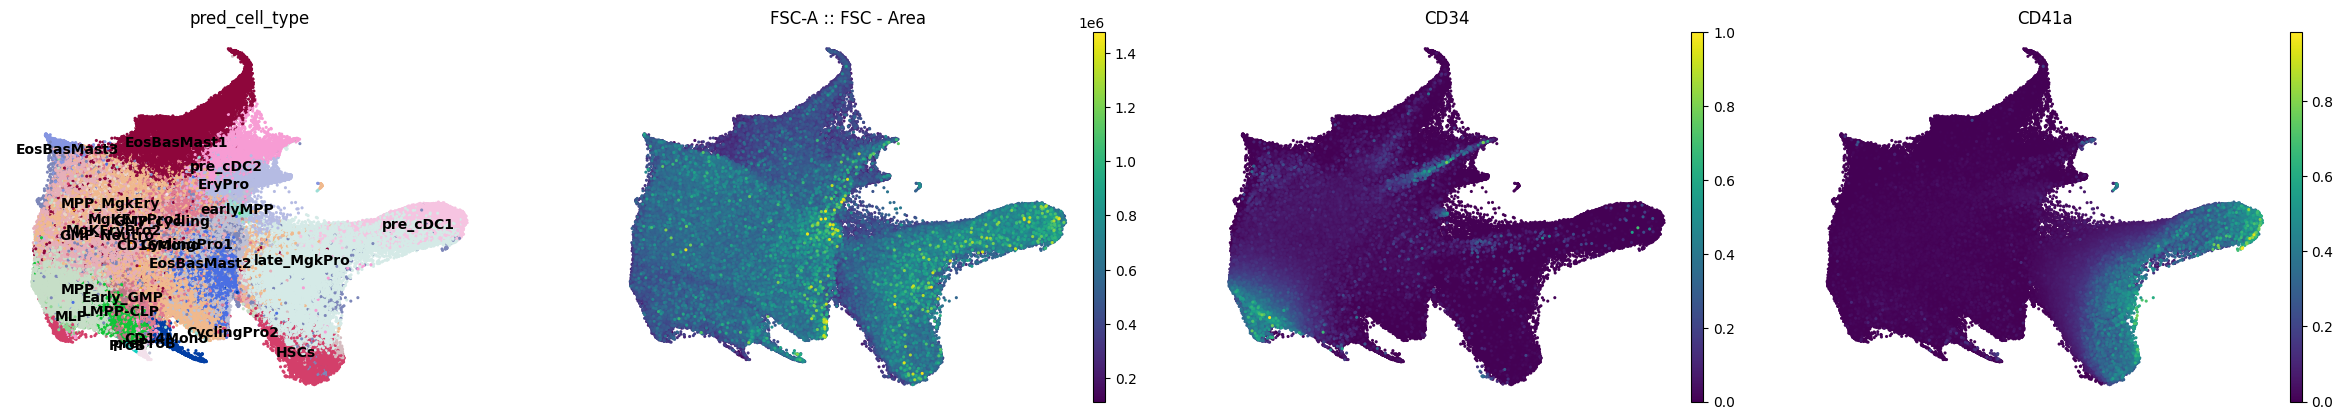

In [ ]:
# compute neighbors and umap
sc.pp.neighbors(adata_500k)
sc.tl.umap(adata_500k)
adata_500k.obs["pred_cell_type"] = ct_pred_500k
sc.pl.embedding(
    adata_500k, "umap", s=20,
    color=["pred_cell_type", "FSC-A :: FSC - Area", "CD34", "CD41a"],
    legend_loc="on data",
    frameon=False,
)

### Create AnnData with Scatter Features. 

In [10]:
# # prepare joint representations
# X_channel_500k = adata_500k.X
# X_scatter_500k = adata_500k.obs[protocol_columns].astype(float).values
# X_500k = np.concatenate(
#     (X_channel_500k, X_scatter_500k),
#     axis=1
# )

# # standardize features
# X_500k_mean = X_500k.mean(0)
# X_500k_std = X_500k.std(0)
# X_500k = (X_500k - X_500k_mean)/X_500k_std

# # create joint anndata
# adata_joint_500k = sc.AnnData(
#     X=X_500k,
#     obs=adata_500k.obs,
#     uns=adata_500k.uns,
# )

# # compute neighbors and umap
# sc.pp.neighbors(adata_joint_500k)
# sc.tl.umap(adata_joint_500k)

In [11]:
# adata_joint_500k.obs["pred_cell_type"] = ct_pred_500k
# sc.pl.embedding(
#     adata_joint_500k, "umap", s=20,
#     color="pred_cell_type",
#     legend_loc="on data",
#     frameon=False,
# )

## HSCs: Compare Size Between New Measurements and Old Measurements.

### Get Original HSCs.

In [45]:
adata_HSCs_orig = adata_500k_orig[adata_500k_orig.obs.cell_type == "HSCs"]
HSCSs_FFSA_orig = adata_HSCs_orig.obs["FSC-A :: FSC - Area"].astype(float).values
HSCSs_CD34_orig = adata_HSCs_orig[:, "CD34"].X[:, 0]
HSCSs_CD41a_orig = adata_HSCs_orig[:, "CD41a"].X[:, 0]
print(HSCSs_FFSA_orig.shape, HSCSs_CD34_orig.shape, HSCSs_CD41a_orig.shape)
adata_HSCs_orig

(2668,) (2668,) (2668,)


View of AnnData object with n_obs × n_vars = 2668 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'leiden', 'leiden_sub', 'leiden_old', 'cell_type'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'leiden_colors

### Get Original MgkPro.

In [39]:
adata_mgk_orig = adata_500k_orig[adata_500k_orig.obs.cell_type == "late_MgkPro"]
mgk_FFSA_orig = adata_mgk_orig.obs["FSC-A :: FSC - Area"].astype(float).values
mgk_CD34_orig = adata_mgk_orig[:, "CD34"].X[:, 0]
mgk_CD41a_orig = adata_mgk_orig[:, "CD41a"].X[:, 0]
print(mgk_FFSA_orig.shape, mgk_CD34_orig.shape, mgk_CD41a_orig.shape)
adata_mgk_orig

(4470,) (4470,) (4470,)


View of AnnData object with n_obs × n_vars = 4470 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'leiden', 'leiden_sub', 'leiden_old', 'cell_type'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'leiden_colors

### Get New HCSs from MgkPro Experiments.

In [65]:
adata_HSCs_new.var_names

Index(['CD49c', 'CD41a', 'CD117', 'CD38', 'HLADR', 'EPCR', 'CD135', 'CD56',
       'CD15', 'CD123', 'CD45', 'CD16', 'CD7', 'CD90', 'CD10', 'CD14',
       'CD45RA', 'CD34', 'CD235a', 'CD19'],
      dtype='object')

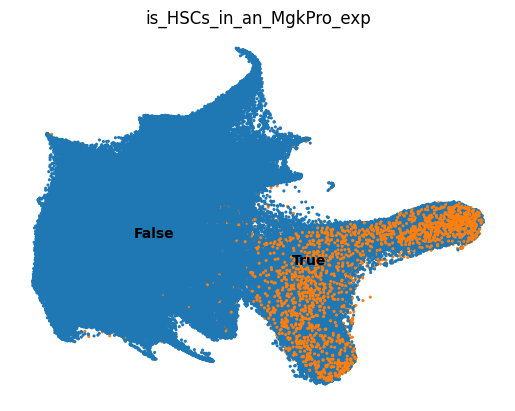

In [70]:

# Keep cells with all markers above percentile
target_quantile = 75
thresholds = np.percentile(adata_HSCs_new[:, "CD41a"].X, target_quantile, axis=0)
keep_mask = np.all(adata_HSCs_new[:, "CD41a"].X >= thresholds, axis=1)
adata_HSCs_new_most_expressing_cd41a = adata_HSCs_new[keep_mask]


adata_HSCs_new_mos_FFSA_orig = adata_HSCs_new_most_expressing_cd41a.obs["FSC-A :: FSC - Area"].astype(float).values
adata_HSCs_new_mos_CD34_orig = adata_HSCs_new_most_expressing_cd41a[:, "CD34"].X[:, 0]
adata_HSCs_new_mos_CD41a_orig = adata_HSCs_new_most_expressing_cd41a[:, "CD41a"].X[:, 0]

adata_500k.obs["is_HSCs_in_an_MgkPro_exp"] = adata_500k.obs.index.map(lambda e: e in adata_HSCs_new_most_expressing_cd41a.obs.index)

sc.pl.embedding(
    adata_500k, "umap", s=20,
    color=["is_HSCs_in_an_MgkPro_exp"],
    legend_loc="on data",
    frameon=False,
)

In [44]:
# filter by MgkPro experiments
mgkpro_experiments = [
    k for k, v in settings_experiments_map.items() if "mgkPro" in v
]
mgkpro_experiments
adata_HSCs_new = adata_500k[adata_500k.obs.pred_cell_type == "HSCs"]
adata_HSCs_new = adata_500k[adata_500k.obs.experiment_number.astype(int).map(lambda e: e in mgkpro_experiments)]
HSCSs_FFSA_new = adata_HSCs_new.obs["FSC-A :: FSC - Area"].astype(float).values
HSCs_CD34_new = adata_HSCs_new[:, "CD34"].X[:, 0]
HSCs_CD41a_new = adata_HSCs_new[:, "CD41a"].X[:, 0]
print(HSCSs_FFSA_new.shape, HSCs_CD34_new.shape, HSCs_CD41a_new.shape)
adata_HSCs_new

(124998,) (124998,) (124998,)


View of AnnData object with n_obs × n_vars = 124998 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'pred_cell_type'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'meta', 'processing_steps', 'neighbors', 'umap', 'pred_cell_type_colors'
    obsm: 'X_scatte

### Get New MgkPro from MgkPro Experiments.

In [47]:
adata_mgk_new = adata_500k[adata_500k.obs.pred_cell_type == "late_MgkPro"]
mgk_FFSA_new = adata_mgk_new.obs["FSC-A :: FSC - Area"].astype(float).values
mgk_CD34_new = adata_mgk_new[:, "CD34"].X[:, 0]
mgk_CD41a_new = adata_mgk_new[:, "CD41a"].X[:, 0]
print(mgk_FFSA_new.shape, mgk_CD34_new.shape, mgk_CD41a_new.shape)
adata_mgk_new

(51451,) (51451,) (51451,)


View of AnnData object with n_obs × n_vars = 51451 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'pred_cell_type'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'meta', 'processing_steps', 'neighbors', 'umap', 'pred_cell_type_colors'
    obsm: 'X_scatter

### Visualize FFSA.

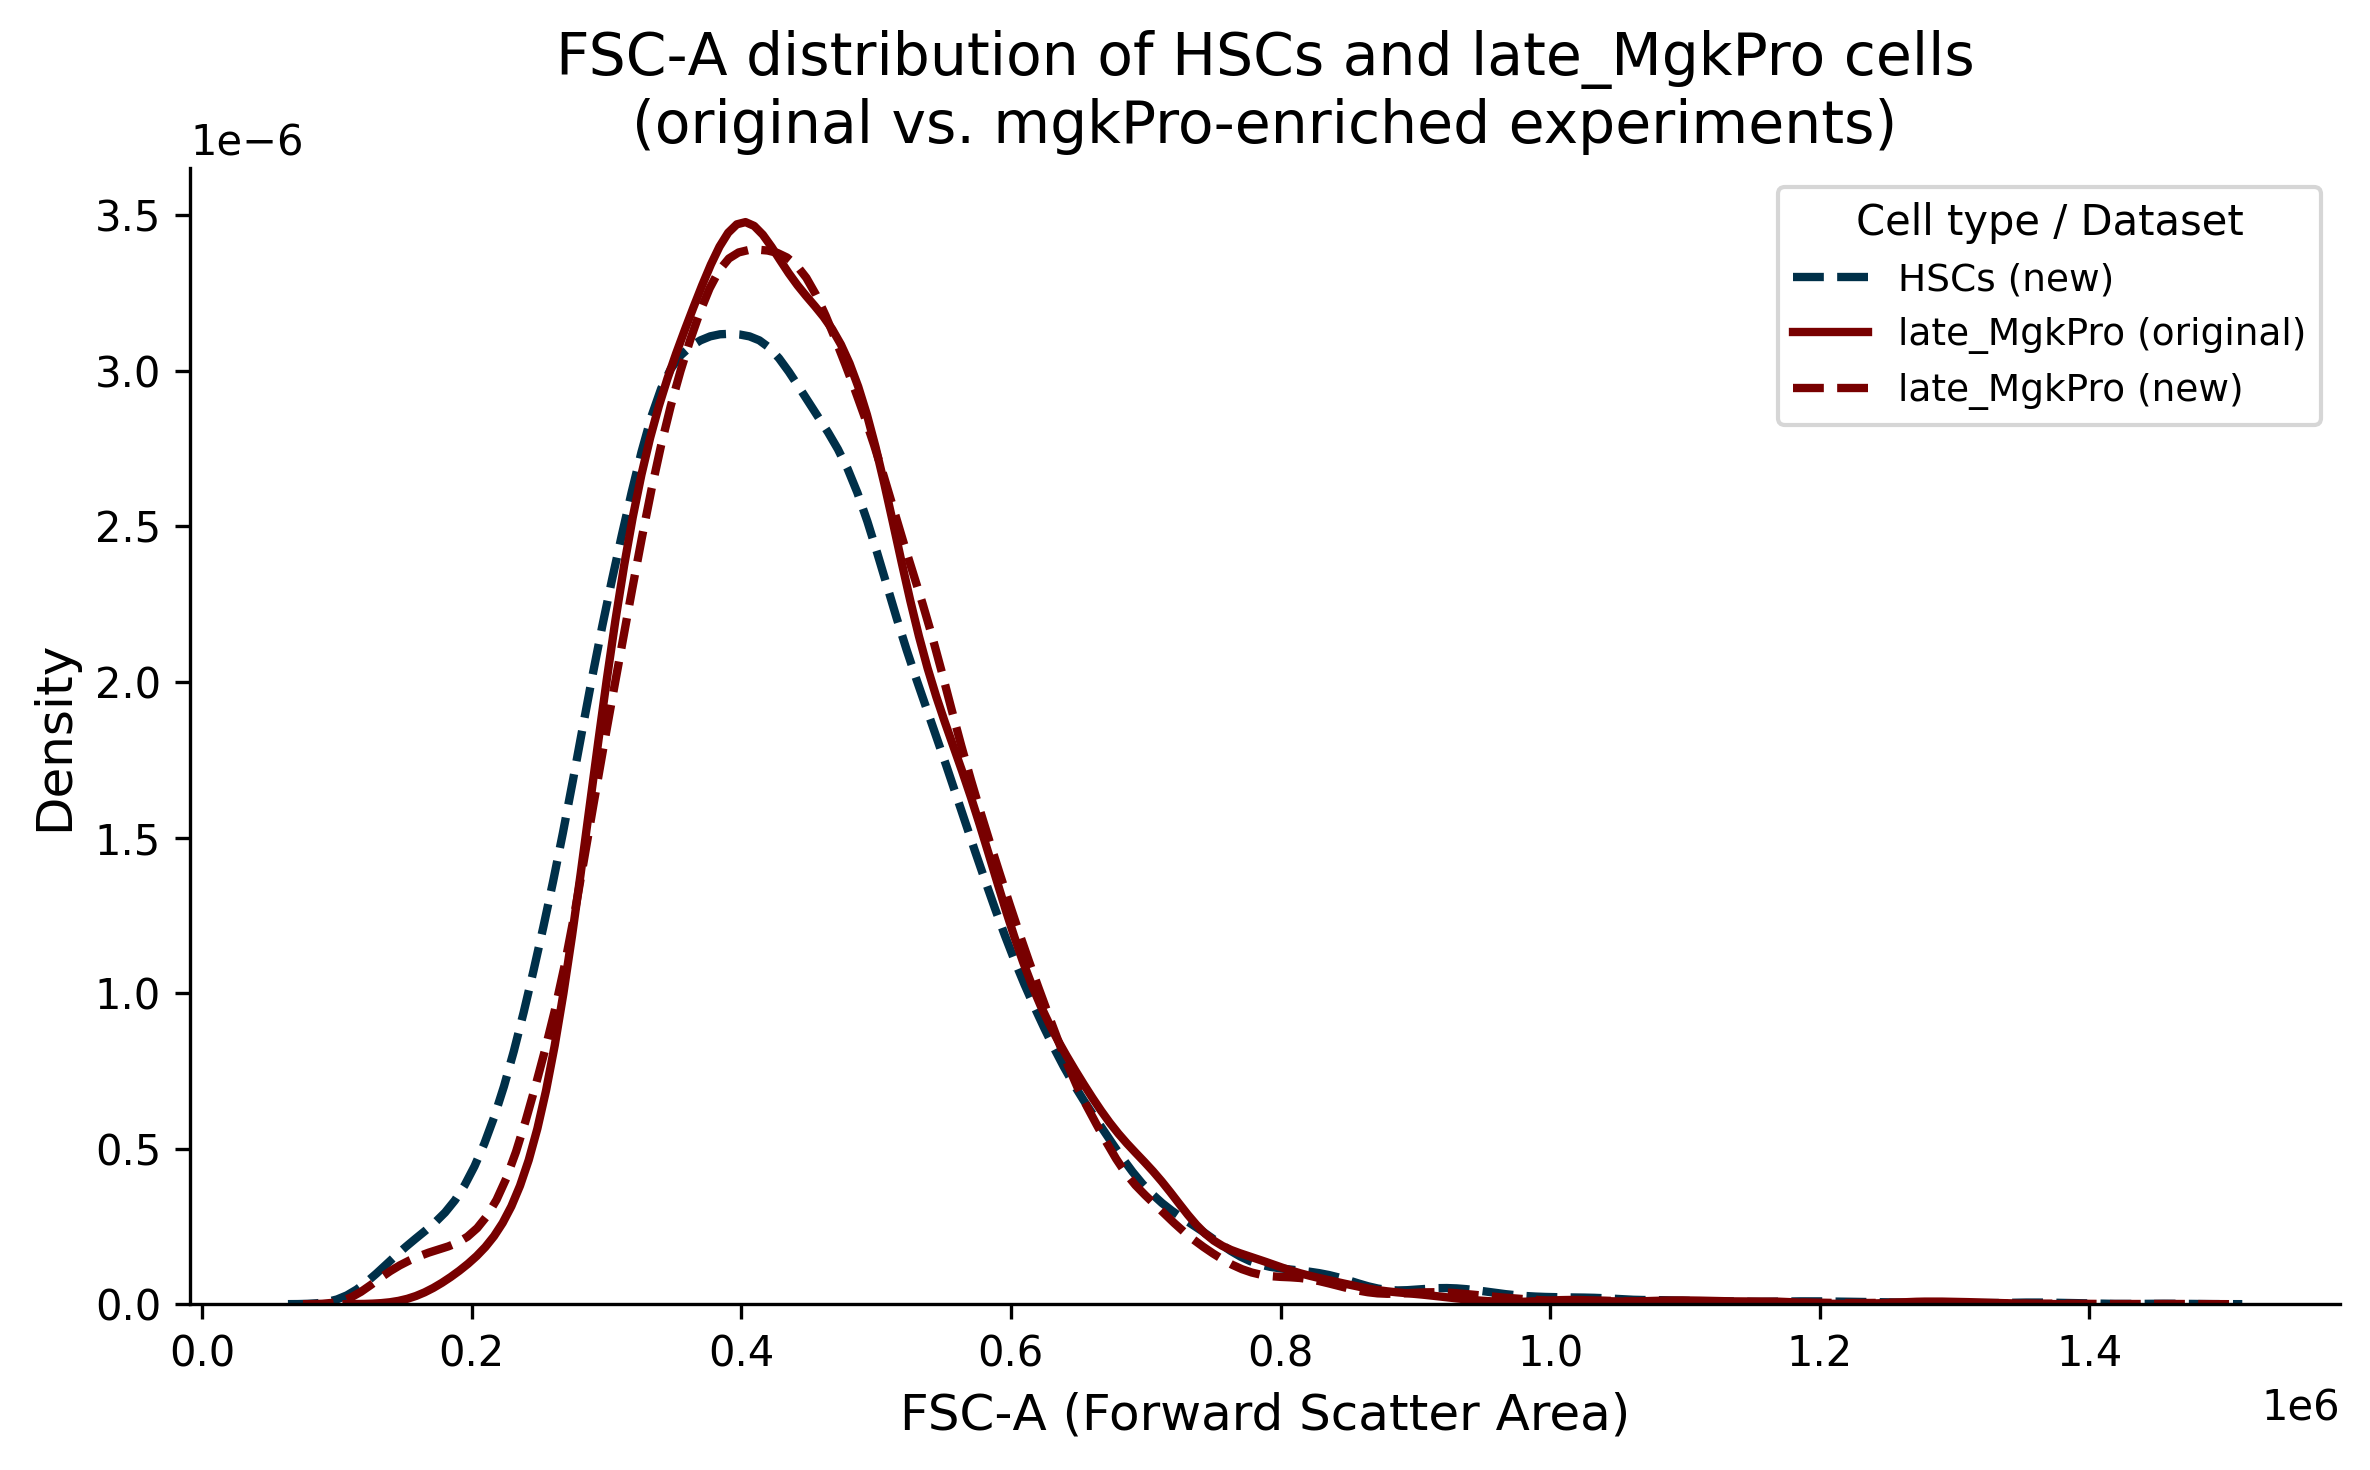

In [71]:
# ------------------------------------------------------------
# 2. Choose colours (cell type specific) and line styles
# ------------------------------------------------------------
# Use two colours from your palette: e.g., HSCs = '#003049' (dark blue), late_MgkPro = '#780000' (burgundy)
color_HSC = '#003049'
color_Mgk = '#780000'

# Line styles: solid for original, dashed for new
style_orig = '-'
style_new  = '--'

# ------------------------------------------------------------
# 3. Create the overlaid density plot
# ------------------------------------------------------------
plt.figure(figsize=(8, 5), dpi=300)

# Plot KDE for HSCs
# sns.kdeplot(HSCs_FFSA_orig, label='HSCs (original)', color=color_HSC, linestyle=style_orig, linewidth=2)
# sns.kdeplot(HSCs_FFSA_new, label='HSCs (new)', color=color_HSC, linestyle=style_new, linewidth=2)

sns.kdeplot(adata_HSCs_new_mos_FFSA_orig, label='HSCs (new)', color=color_HSC, linestyle=style_new, linewidth=2)

# Plot KDE for late_MgkPro
sns.kdeplot(mgk_FFSA_orig, label='late_MgkPro (original)', color=color_Mgk, linestyle=style_orig, linewidth=2)
sns.kdeplot(mgk_FFSA_new, label='late_MgkPro (new)', color=color_Mgk, linestyle=style_new, linewidth=2)

# Labels, title, legend
plt.xlabel('FSC‑A (Forward Scatter Area)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('FSC‑A distribution of HSCs and late_MgkPro cells\n(original vs. mgkPro‑enriched experiments)', fontsize=14)

plt.legend(title='Cell type / Dataset', title_fontsize=10, fontsize=9)
sns.despine()  # remove top/right spines
plt.tight_layout()
# plt.savefig('output/FSCA_distributions_original_vs_new.png', dpi=300, bbox_inches='tight')
plt.show()

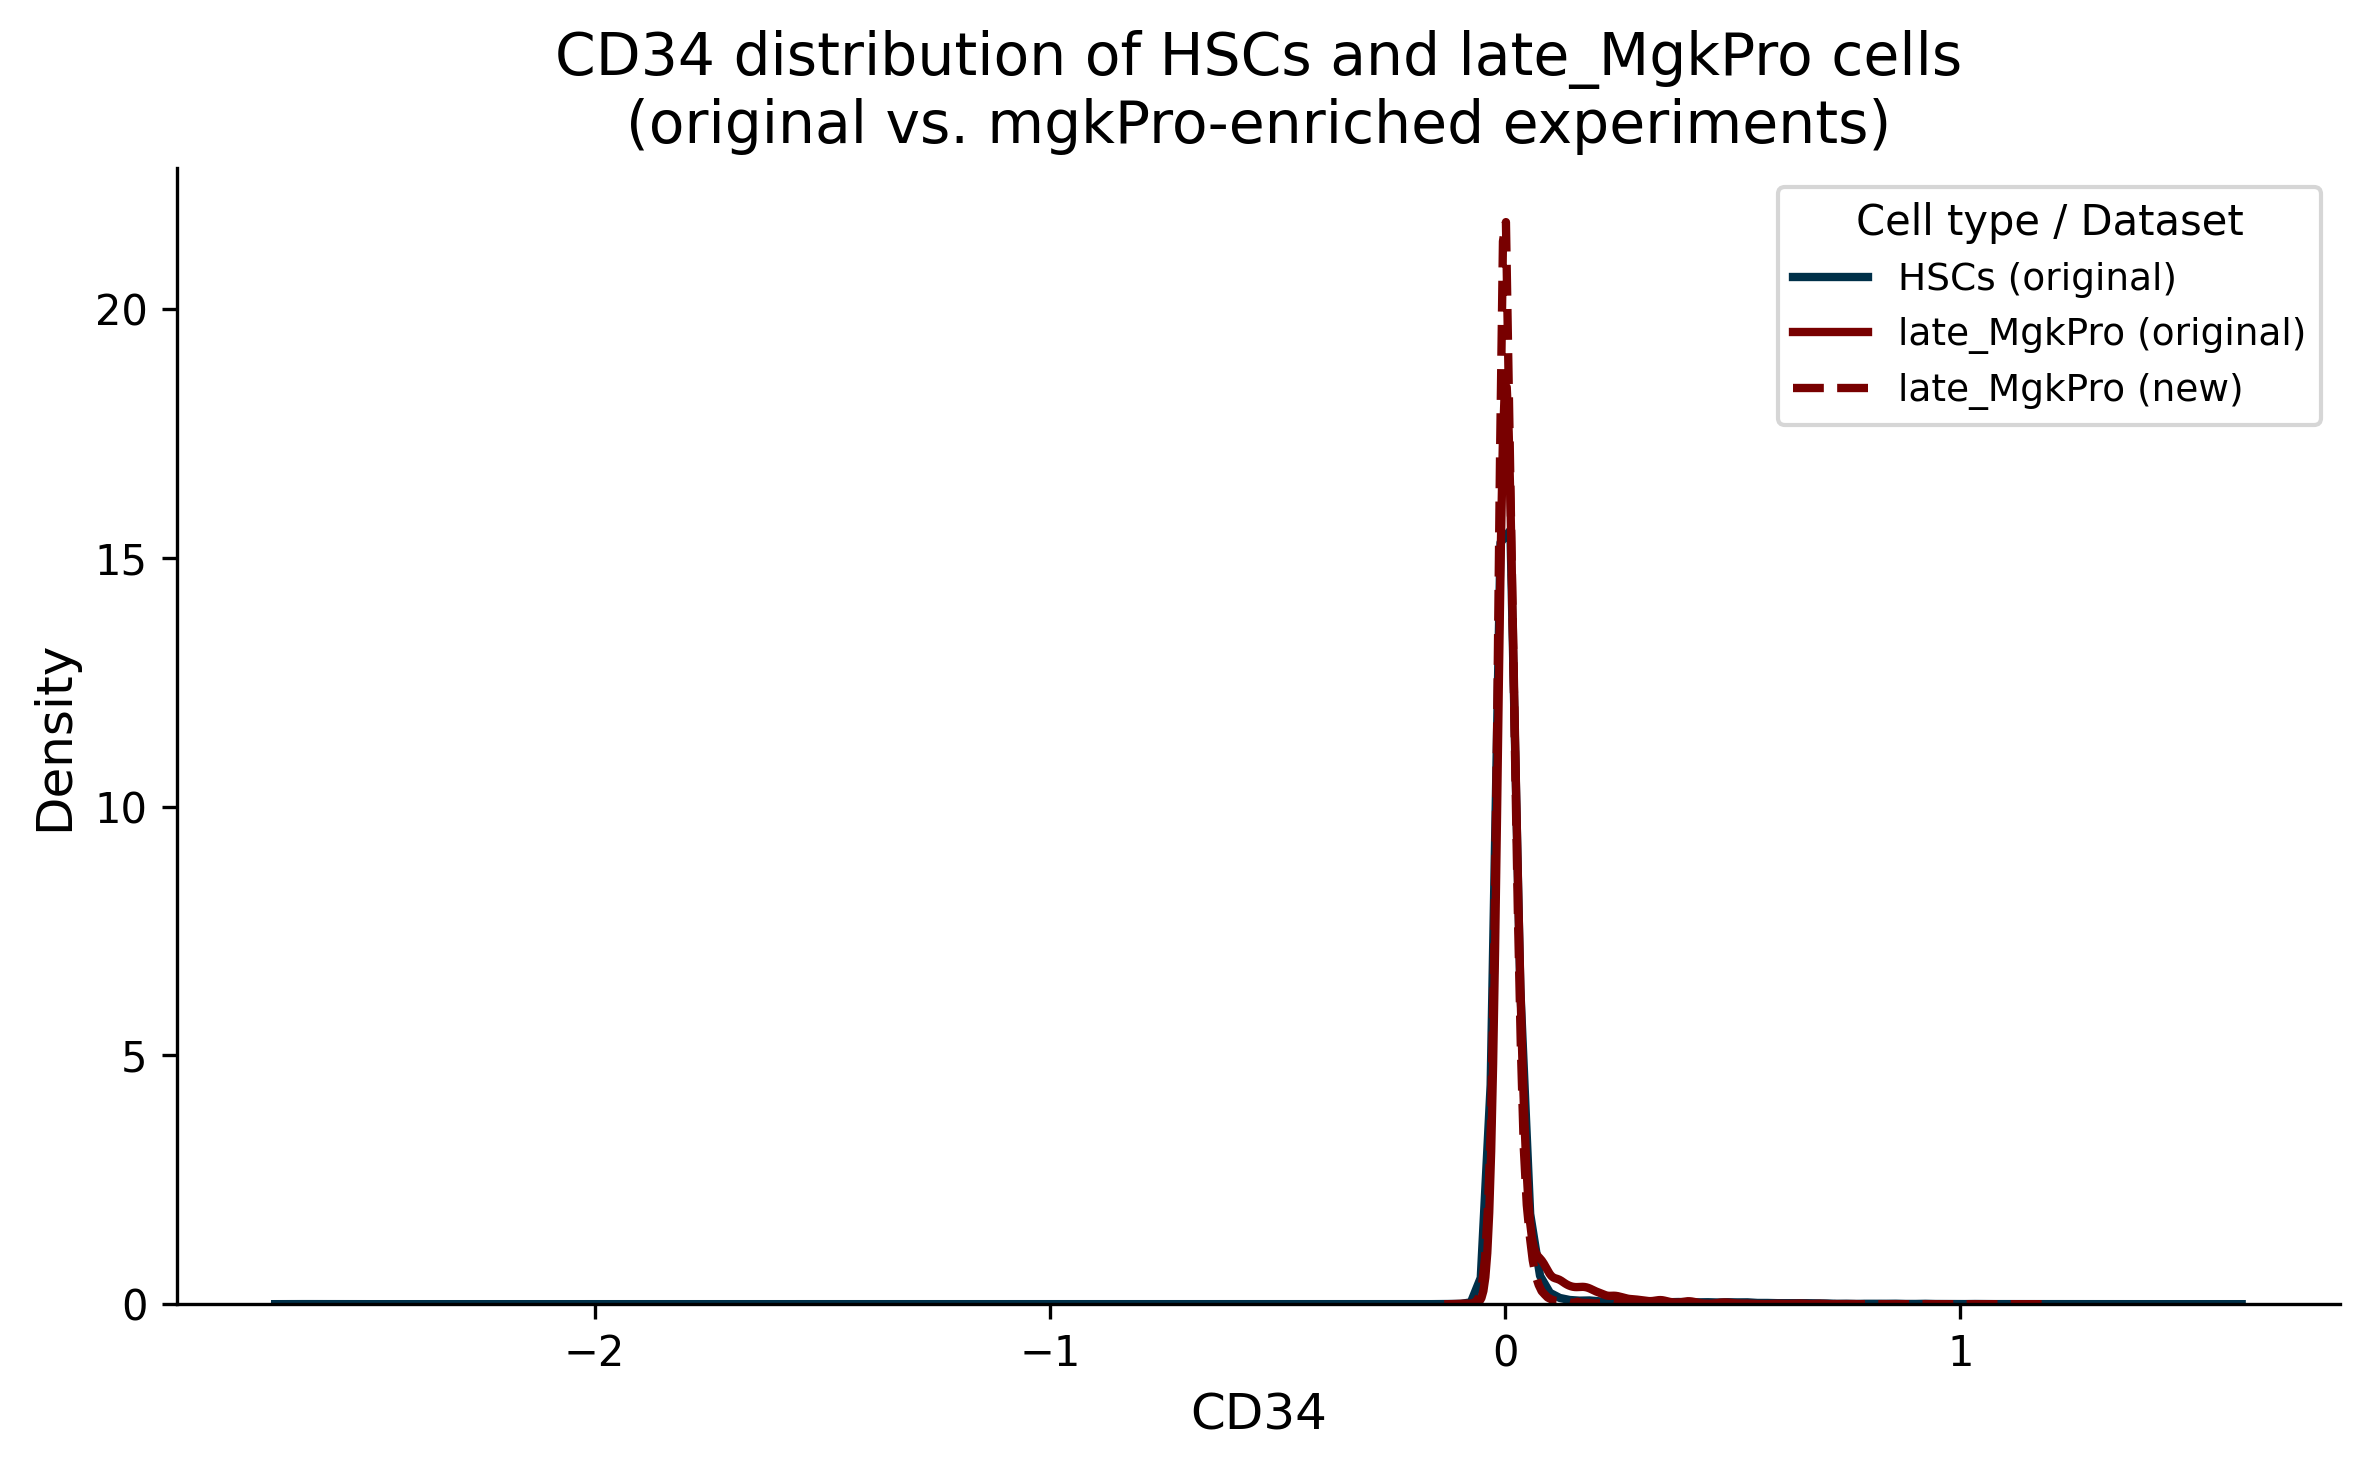

In [72]:
# ------------------------------------------------------------
# 2. Choose colours (cell type specific) and line styles
# ------------------------------------------------------------
# Use two colours from your palette: e.g., HSCs = '#003049' (dark blue), late_MgkPro = '#780000' (burgundy)
color_HSC = '#003049'
color_Mgk = '#780000'

# Line styles: solid for original, dashed for new
style_orig = '-'
style_new  = '--'

# ------------------------------------------------------------
# 3. Create the overlaid density plot
# ------------------------------------------------------------
plt.figure(figsize=(8, 5), dpi=300)

# Plot KDE for HSCs
# sns.kdeplot(HSCs_CD34_orig, label='HSCs (original)', color=color_HSC, linestyle=style_orig, linewidth=2)
# sns.kdeplot(HSCs_CD34_new, label='HSCs (new)', color=color_HSC, linestyle=style_new, linewidth=2)

sns.kdeplot(adata_HSCs_new_mos_CD34_orig, label='HSCs (original)', color=color_HSC, linestyle=style_orig, linewidth=2)
# sns.kdeplot(HSCs_CD34_new, label='HSCs (new)', color=color_HSC, linestyle=style_new, linewidth=2)

# Plot KDE for late_MgkPro
sns.kdeplot(mgk_CD34_orig, label='late_MgkPro (original)', color=color_Mgk, linestyle=style_orig, linewidth=2)
sns.kdeplot(mgk_CD34_new, label='late_MgkPro (new)', color=color_Mgk, linestyle=style_new, linewidth=2)

# Labels, title, legend
plt.xlabel('CD34', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('CD34 distribution of HSCs and late_MgkPro cells\n(original vs. mgkPro‑enriched experiments)', fontsize=14)

plt.legend(title='Cell type / Dataset', title_fontsize=10, fontsize=9)
sns.despine()  # remove top/right spines
plt.tight_layout()
# plt.savefig('output/FSCA_distributions_original_vs_new.png', dpi=300, bbox_inches='tight')
plt.show()

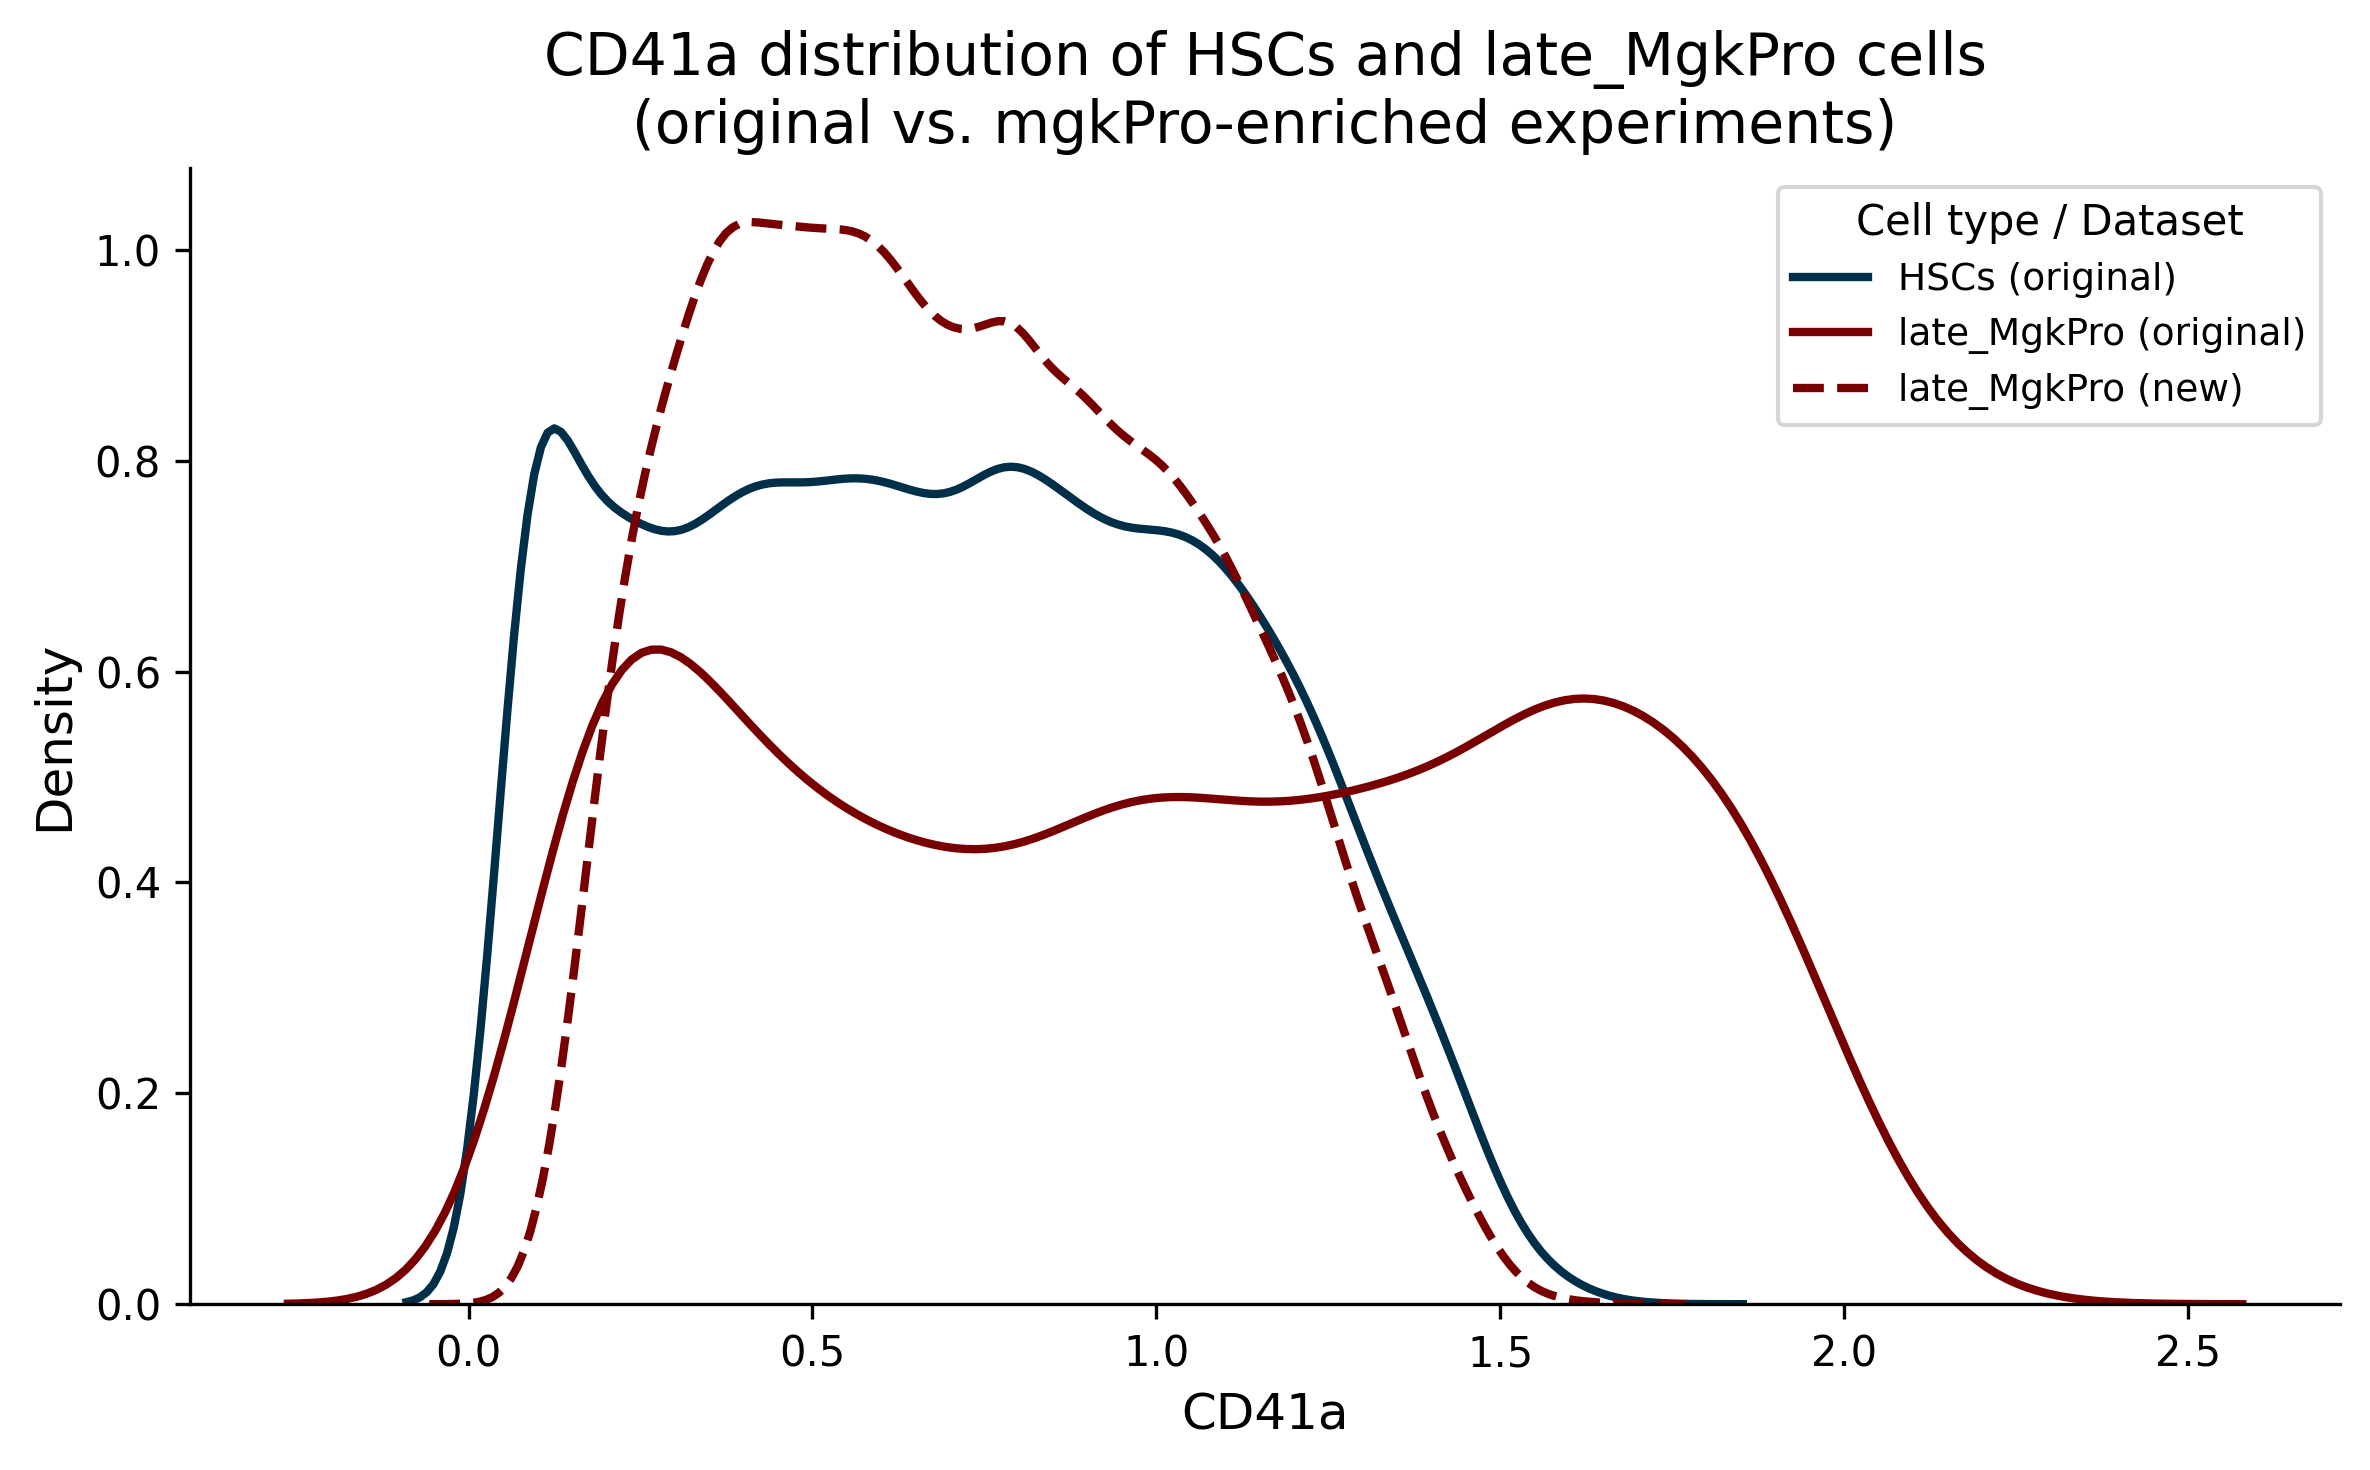

In [73]:
# ------------------------------------------------------------
# 2. Choose colours (cell type specific) and line styles
# ------------------------------------------------------------
# Use two colours from your palette: e.g., HSCs = '#003049' (dark blue), late_MgkPro = '#780000' (burgundy)
color_HSC = '#003049'
color_Mgk = '#780000'

# Line styles: solid for original, dashed for new
style_orig = '-'
style_new  = '--'

# ------------------------------------------------------------
# 3. Create the overlaid density plot
# ------------------------------------------------------------
plt.figure(figsize=(8, 5), dpi=300)

# Plot KDE for HSCs
# sns.kdeplot(HSCs_CD41a_orig, label='HSCs (original)', color=color_HSC, linestyle=style_orig, linewidth=2)
# sns.kdeplot(HSCs_CD41a_new, label='HSCs (new)', color=color_HSC, linestyle=style_new, linewidth=2)

sns.kdeplot(adata_HSCs_new_mos_CD41a_orig, label='HSCs (original)', color=color_HSC, linestyle=style_orig, linewidth=2)

# Plot KDE for late_MgkPro
sns.kdeplot(mgk_CD41a_orig, label='late_MgkPro (original)', color=color_Mgk, linestyle=style_orig, linewidth=2)
sns.kdeplot(mgk_CD41a_new, label='late_MgkPro (new)', color=color_Mgk, linestyle=style_new, linewidth=2)

# Labels, title, legend
plt.xlabel('CD41a', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('CD41a distribution of HSCs and late_MgkPro cells\n(original vs. mgkPro‑enriched experiments)', fontsize=14)

plt.legend(title='Cell type / Dataset', title_fontsize=10, fontsize=9)
sns.despine()  # remove top/right spines
plt.tight_layout()
# plt.savefig('output/FSCA_distributions_original_vs_new.png', dpi=300, bbox_inches='tight')
plt.show()

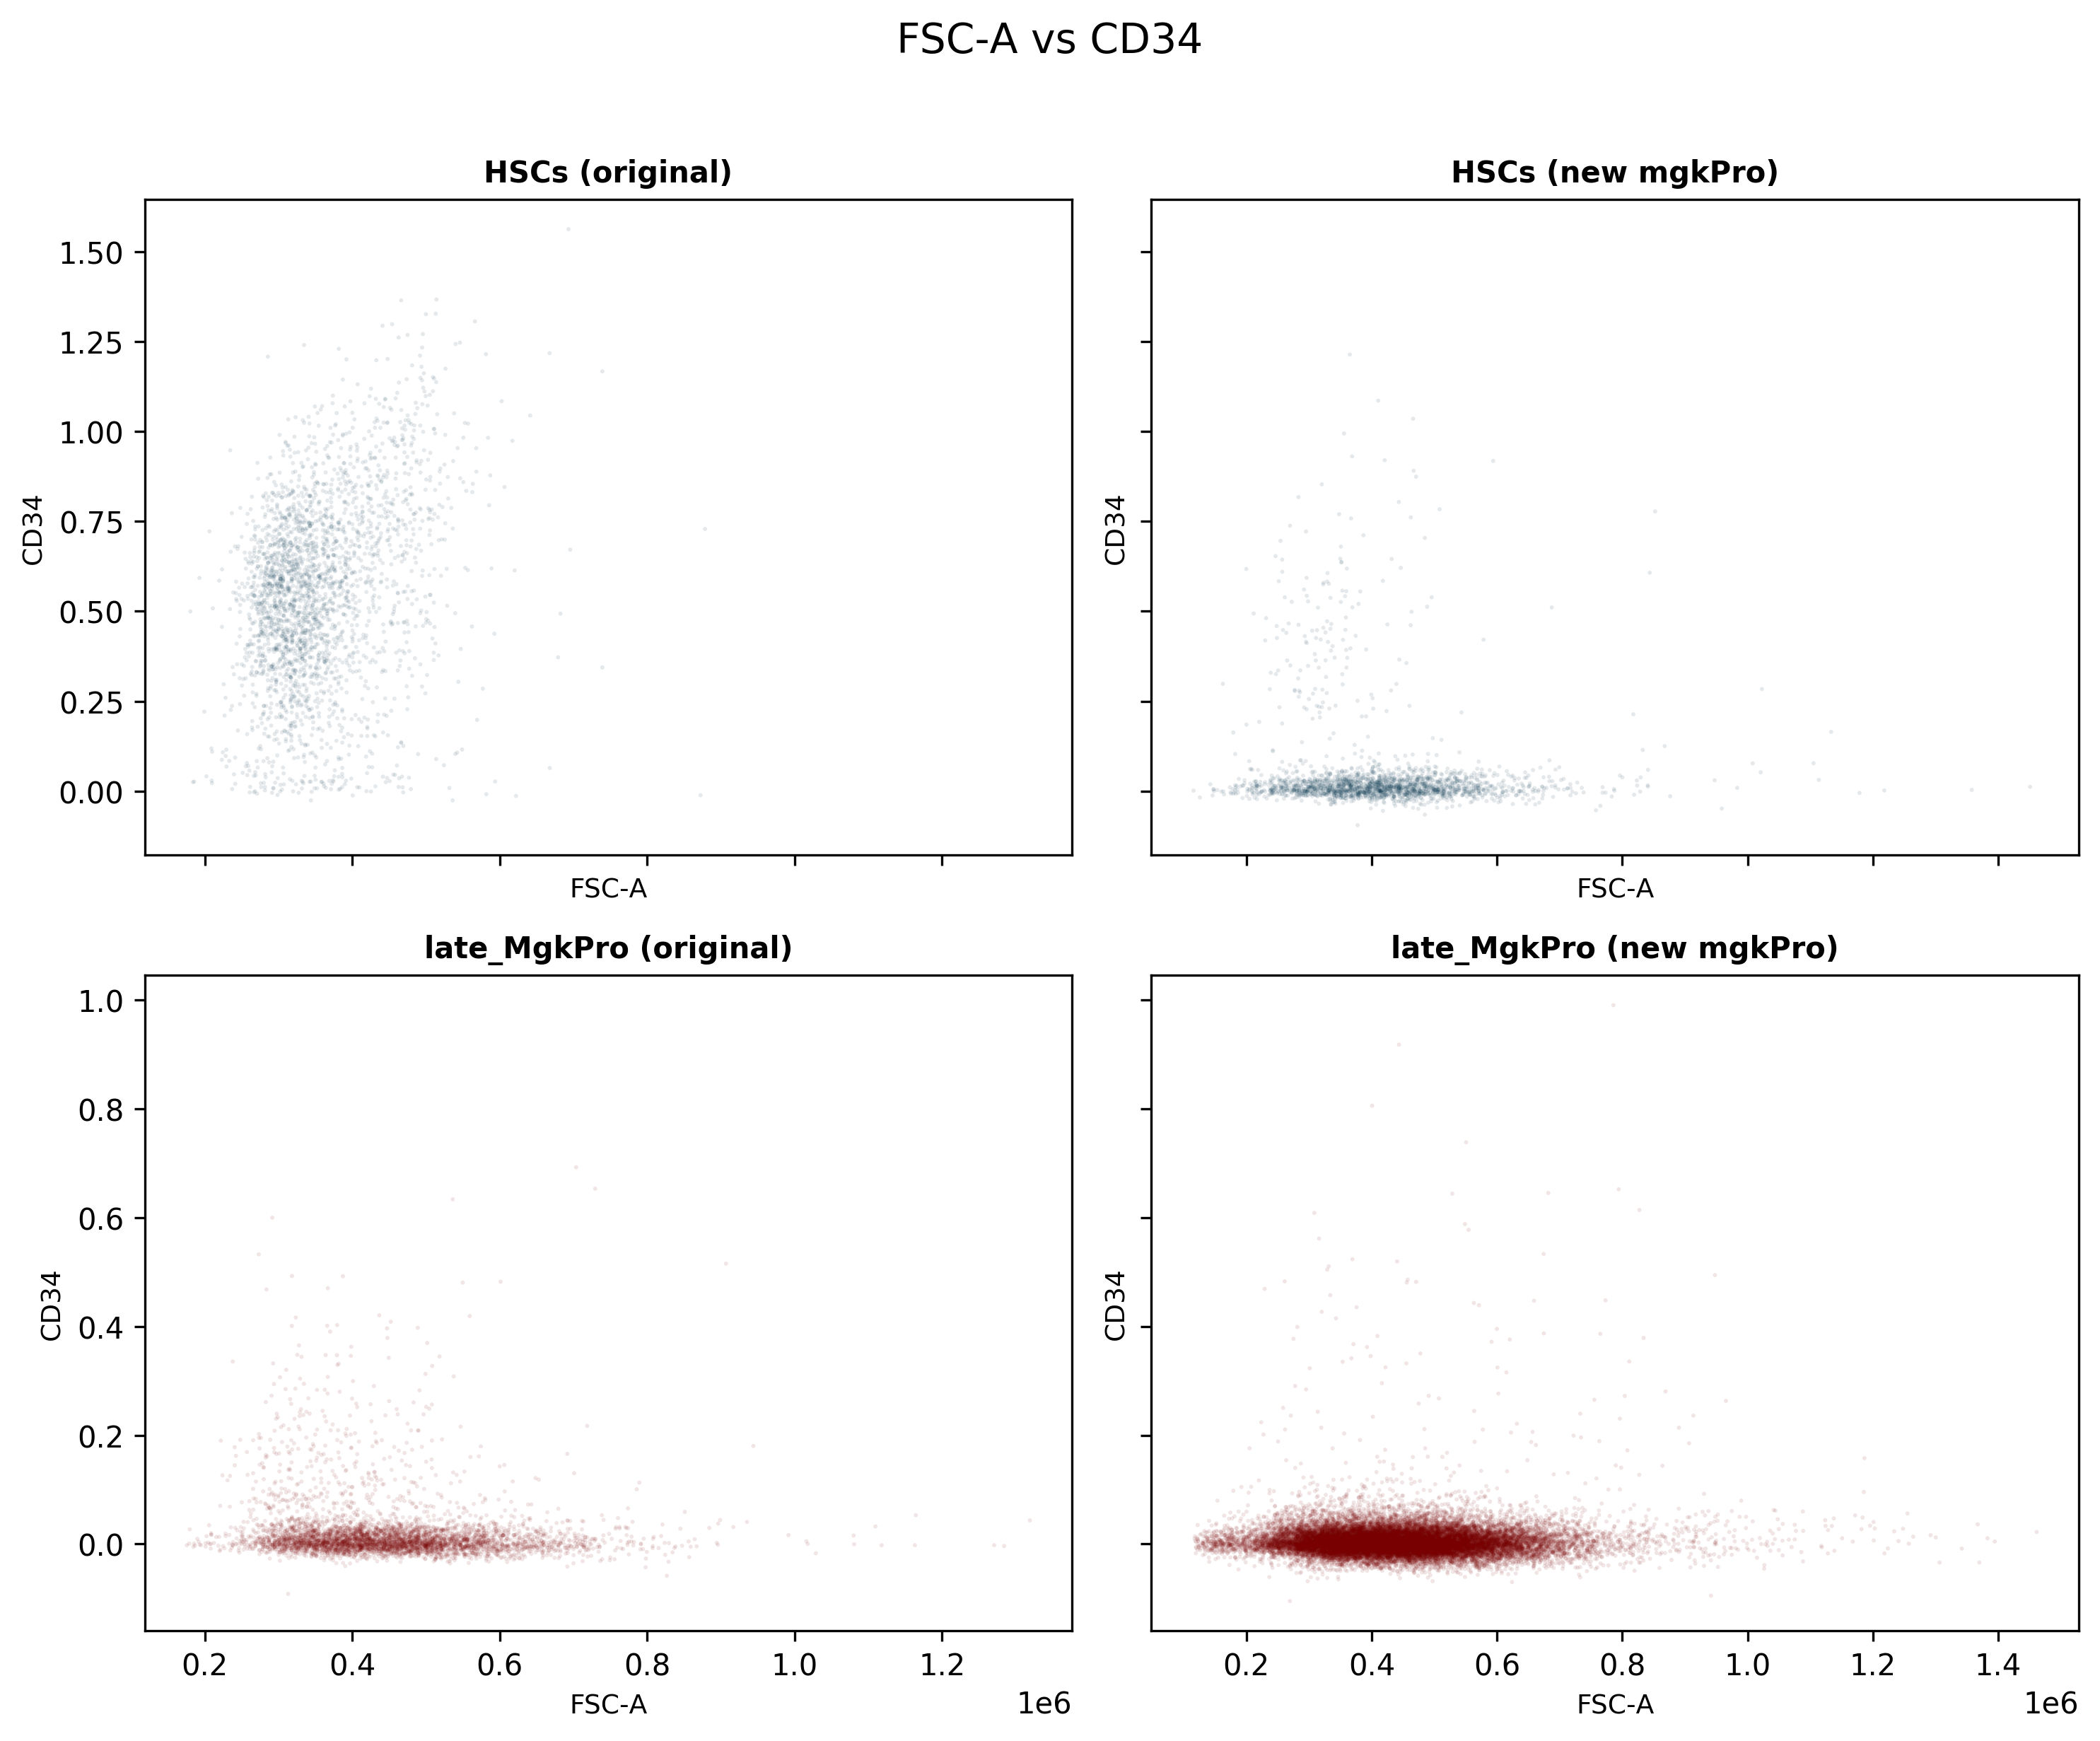

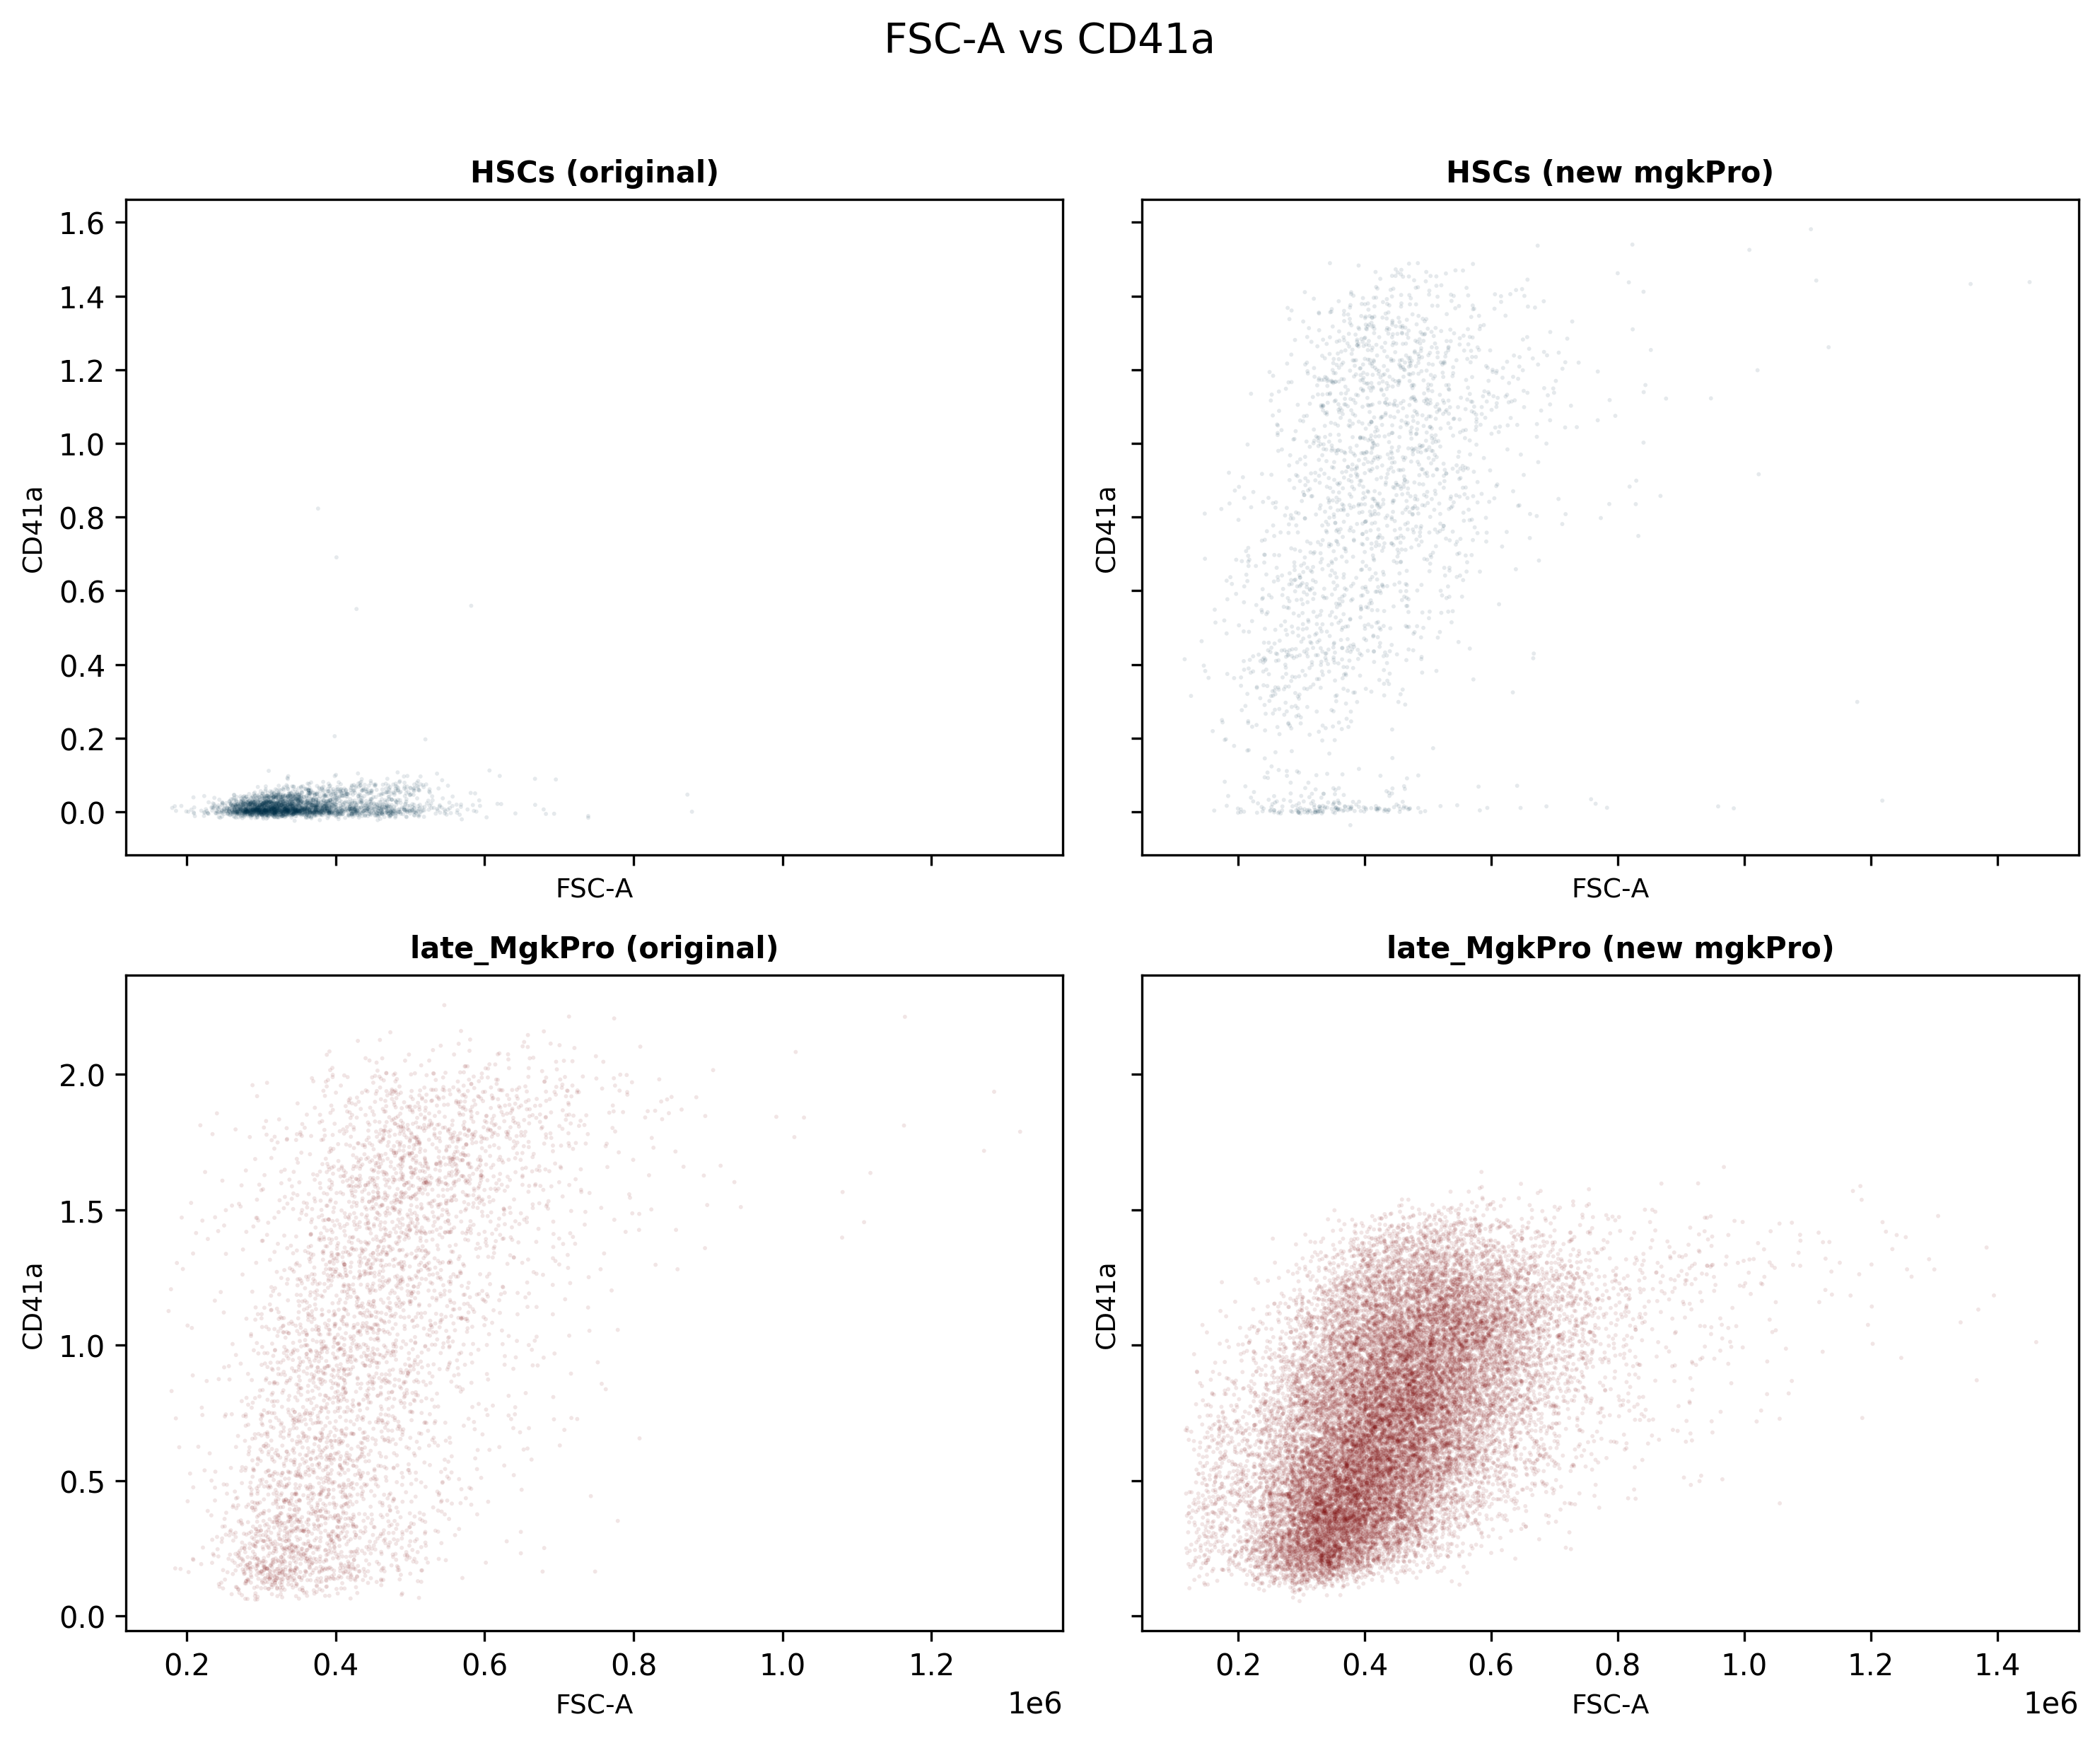

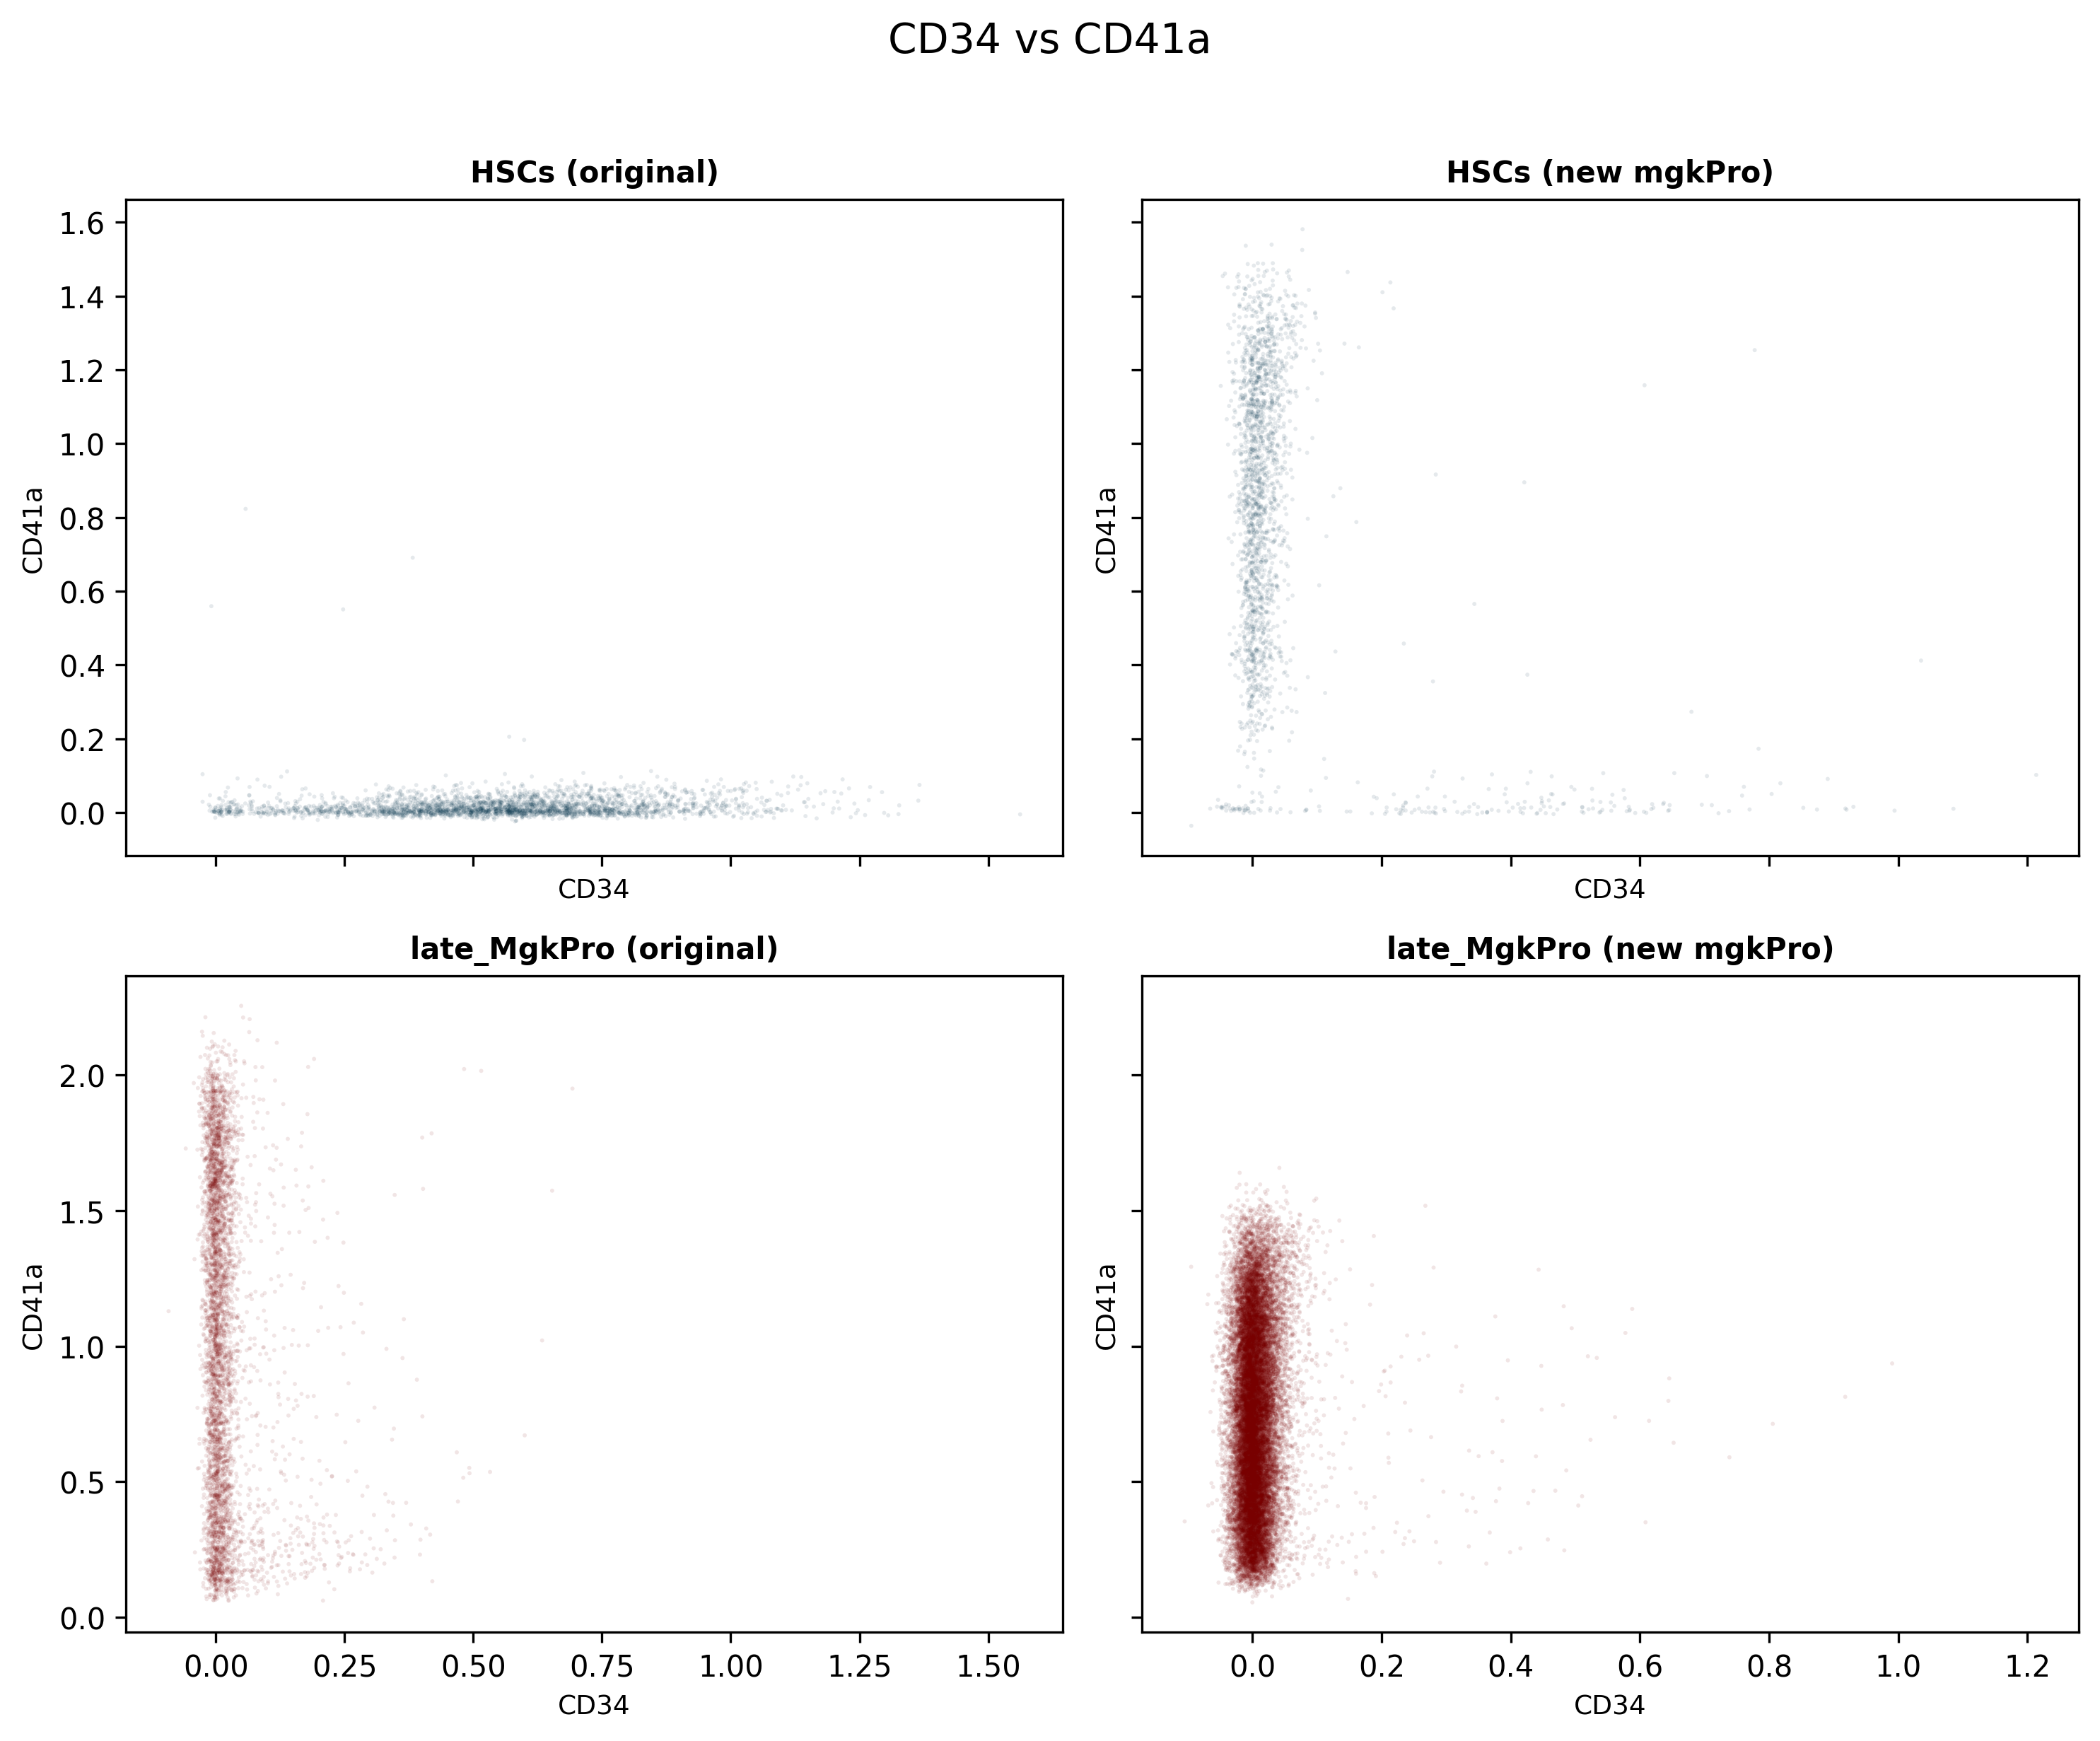

In [75]:
# ------------------------------------------------------------
# 1. Correct data extraction (fix the overwriting bug)
# ------------------------------------------------------------
mgkpro_experiments = [k for k, v in settings_experiments_map.items() if "mgkPro" in v]

# Original data (already correct)
adata_HSCs_orig = adata_500k_orig[adata_500k_orig.obs.cell_type == "HSCs"]
HSCs_FFSA_orig = adata_HSCs_orig.obs["FSC-A :: FSC - Area"].astype(float).values
HSCs_CD34_orig = adata_HSCs_orig[:, "CD34"].X[:, 0].A.flatten() if hasattr(adata_HSCs_orig[:, "CD34"].X, "A") else adata_HSCs_orig[:, "CD34"].X[:, 0]
HSCs_CD41a_orig = adata_HSCs_orig[:, "CD41a"].X[:, 0].A.flatten() if hasattr(adata_HSCs_orig[:, "CD41a"].X, "A") else adata_HSCs_orig[:, "CD41a"].X[:, 0]

adata_mgk_orig = adata_500k_orig[adata_500k_orig.obs.cell_type == "late_MgkPro"]
mgk_FFSA_orig = adata_mgk_orig.obs["FSC-A :: FSC - Area"].astype(float).values
mgk_CD34_orig = adata_mgk_orig[:, "CD34"].X[:, 0].A.flatten() if hasattr(adata_mgk_orig[:, "CD34"].X, "A") else adata_mgk_orig[:, "CD34"].X[:, 0]
mgk_CD41a_orig = adata_mgk_orig[:, "CD41a"].X[:, 0].A.flatten() if hasattr(adata_mgk_orig[:, "CD41a"].X, "A") else adata_mgk_orig[:, "CD41a"].X[:, 0]

# New data (fixed filtering)
adata_HSCs_new = adata_500k[adata_500k.obs.pred_cell_type == "HSCs"]
adata_HSCs_new = adata_HSCs_new[adata_HSCs_new.obs.experiment_number.astype(int).isin(mgkpro_experiments)]
HSCs_FFSA_new = adata_HSCs_new.obs["FSC-A :: FSC - Area"].astype(float).values
HSCs_CD34_new = adata_HSCs_new[:, "CD34"].X[:, 0].A.flatten() if hasattr(adata_HSCs_new[:, "CD34"].X, "A") else adata_HSCs_new[:, "CD34"].X[:, 0]
HSCs_CD41a_new = adata_HSCs_new[:, "CD41a"].X[:, 0].A.flatten() if hasattr(adata_HSCs_new[:, "CD41a"].X, "A") else adata_HSCs_new[:, "CD41a"].X[:, 0]

adata_mgk_new = adata_500k[adata_500k.obs.pred_cell_type == "late_MgkPro"]
adata_mgk_new = adata_mgk_new[adata_mgk_new.obs.experiment_number.astype(int).isin(mgkpro_experiments)]
mgk_FFSA_new = adata_mgk_new.obs["FSC-A :: FSC - Area"].astype(float).values
mgk_CD34_new = adata_mgk_new[:, "CD34"].X[:, 0].A.flatten() if hasattr(adata_mgk_new[:, "CD34"].X, "A") else adata_mgk_new[:, "CD34"].X[:, 0]
mgk_CD41a_new = adata_mgk_new[:, "CD41a"].X[:, 0].A.flatten() if hasattr(adata_mgk_new[:, "CD41a"].X, "A") else adata_mgk_new[:, "CD41a"].X[:, 0]

# ------------------------------------------------------------
# 2. Define colours and labels
# ------------------------------------------------------------
color_HSC = '#003049'    # dark blue from your palette
color_Mgk = '#780000'    # burgundy from your palette

# ------------------------------------------------------------
# 3. Helper function to create a hexbin scatter plot (handles large n)
# ------------------------------------------------------------
def hexbin_scatter(ax, x, y, color, xlabel, ylabel, title, bins='log'):
    """Add a hexbin plot to an axis for large datasets."""
    hb = ax.hexbin(x, y, gridsize=60, cmap='Greys', mincnt=1, bins=bins)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=10, weight='bold')
    # Set face color of hexagons? Actually hexbin uses colormap; we want single color? 
    # To get a single colour with transparency, we use scatter with alpha, but hexbin is faster.
    # Alternative: use scatter with alpha=0.1 and edgecolor='none'.
    # For simplicity and speed, we'll use scatter with small alpha.
    # Replace with scatter if hexbin doesn't match desired look.
    # Let's use scatter with alpha=0.05 and color.
    return

# We'll use scatter with alpha for better colour control
def scatter_density(ax, x, y, color, xlabel, ylabel, title, alpha=0.05, s=1):
    ax.scatter(x, y, c=color, alpha=alpha, s=s, edgecolors='none', rasterized=True)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=10, weight='bold')
    # Optionally set axis limits to 5th-95th percentile for clarity
    # but we'll keep auto scaling.

# ------------------------------------------------------------
# 4. Create three separate figures (one per marker pair)
# ------------------------------------------------------------
# Figure 1: FSC‑A vs CD34
fig1, axes = plt.subplots(2, 2, figsize=(10, 8), dpi=300, sharex='col', sharey='row')
# Row: HSC (top), Mgk (bottom); Col: original (left), new (right)
# HSC original
scatter_density(axes[0,0], HSCs_FFSA_orig, HSCs_CD34_orig, color_HSC, 
                'FSC‑A', 'CD34', 'HSCs (original)', alpha=0.1, s=2)
# HSC new
scatter_density(axes[0,1], HSCs_FFSA_new, HSCs_CD34_new, color_HSC, 
                'FSC‑A', 'CD34', 'HSCs (new mgkPro)', alpha=0.1, s=2)
# Mgk original
scatter_density(axes[1,0], mgk_FFSA_orig, mgk_CD34_orig, color_Mgk, 
                'FSC‑A', 'CD34', 'late_MgkPro (original)', alpha=0.1, s=2)
# Mgk new
scatter_density(axes[1,1], mgk_FFSA_new, mgk_CD34_new, color_Mgk, 
                'FSC‑A', 'CD34', 'late_MgkPro (new mgkPro)', alpha=0.1, s=2)

fig1.suptitle('FSC‑A vs CD34', fontsize=14, y=1.02)
plt.tight_layout()
# plt.savefig('output/scatter_FSCA_CD34.png', bbox_inches='tight', dpi=300)
plt.show()

# Figure 2: FSC‑A vs CD41a
fig2, axes = plt.subplots(2, 2, figsize=(10, 8), dpi=300, sharex='col', sharey='row')
scatter_density(axes[0,0], HSCs_FFSA_orig, HSCs_CD41a_orig, color_HSC, 
                'FSC‑A', 'CD41a', 'HSCs (original)', alpha=0.1, s=2)
scatter_density(axes[0,1], HSCs_FFSA_new, HSCs_CD41a_new, color_HSC, 
                'FSC‑A', 'CD41a', 'HSCs (new mgkPro)', alpha=0.1, s=2)
scatter_density(axes[1,0], mgk_FFSA_orig, mgk_CD41a_orig, color_Mgk, 
                'FSC‑A', 'CD41a', 'late_MgkPro (original)', alpha=0.1, s=2)
scatter_density(axes[1,1], mgk_FFSA_new, mgk_CD41a_new, color_Mgk, 
                'FSC‑A', 'CD41a', 'late_MgkPro (new mgkPro)', alpha=0.1, s=2)

fig2.suptitle('FSC‑A vs CD41a', fontsize=14, y=1.02)
plt.tight_layout()
# plt.savefig('output/scatter_FSCA_CD41a.png', bbox_inches='tight', dpi=300)
plt.show()

# Figure 3: CD34 vs CD41a
fig3, axes = plt.subplots(2, 2, figsize=(10, 8), dpi=300, sharex='col', sharey='row')
scatter_density(axes[0,0], HSCs_CD34_orig, HSCs_CD41a_orig, color_HSC, 
                'CD34', 'CD41a', 'HSCs (original)', alpha=0.1, s=2)
scatter_density(axes[0,1], HSCs_CD34_new, HSCs_CD41a_new, color_HSC, 
                'CD34', 'CD41a', 'HSCs (new mgkPro)', alpha=0.1, s=2)
scatter_density(axes[1,0], mgk_CD34_orig, mgk_CD41a_orig, color_Mgk, 
                'CD34', 'CD41a', 'late_MgkPro (original)', alpha=0.1, s=2)
scatter_density(axes[1,1], mgk_CD34_new, mgk_CD41a_new, color_Mgk, 
                'CD34', 'CD41a', 'late_MgkPro (new mgkPro)', alpha=0.1, s=2)

fig3.suptitle('CD34 vs CD41a', fontsize=14, y=1.02)
plt.tight_layout()
# plt.savefig('output/scatter_CD34_CD41a.png', bbox_inches='tight', dpi=300)
plt.show()